# Import library

In [9]:
# 安裝套件
!pip install torch torchvision torchaudio

  Using cached torch-2.11.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (5.5 kB)
  Using cached torchaudio-2.11.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (6.9 kB)
Using cached torch-2.11.0-cp313-cp313-macosx_11_0_arm64.whl (80.6 MB)
Using cached torchvision-0.26.0-cp313-cp313-macosx_12_0_arm64.whl (1.9 MB)
Using cached torchaudio-2.11.0-cp313-cp313-macosx_12_0_arm64.whl (679 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torchvision]━━━━━━ 2/3 [torchvision]


In [34]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 3.8 MB/s eta 0:00:000:00:010:00:01:01
  Installing build dependencies ...done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 2.3 MB/s eta 0:00:00m eta 0:00:010:00:01
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=5a6a22ccef713bbf99692691d262fbc0d508f57388a485ce4075cab021c8b750
  Stored in directory: /Users/claireweng/Library/Caches/pip/wheels/b9/1c/2d/281a1509651a08cada4dd95a63ee095f00f234b6a96d61c089
Successfully built grad-cam
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [grad-cam]━━ 1/3 [opencv-python]


In [1]:
import torch
import torch.nn.functional as F
from torchsummary import summary
import pandas as pd
import numpy as np
import os
import platform
from sklearn.model_selection import train_test_split
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm  

# 檢測最佳設備
if torch.backends.mps.is_available():
    device = torch.device("mps")
    train_on_gpu = True
    print(f"✅ 正在使用 Apple Silicon GPU (MPS) | 晶片: {platform.processor()}")
    
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
    
elif torch.cuda.is_available():
    device = torch.device("cuda:0")
    train_on_gpu = True
    print(f"✅ 正在使用 NVIDIA GPU (CUDA): {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    train_on_gpu = False
    print("⚠️ 找不到 GPU 加速環境，將使用 CPU 進行訓練")


✅ 正在使用 Apple Silicon GPU (MPS) | 晶片: arm


# exploratory data analysis

In [2]:
# 讀取 .csv 文件
csv_path = "train_data.csv"  
image_base_dir = "./train"   # 影像資料夾
data = pd.read_csv(csv_path)

# 提取 SOPInstanceUID 和 Target
sop_instance_uids = data['SOPInstanceUID'].values
original_labels = data['Target'].values

# 動態生成影像的完整路徑
image_paths = [os.path.join(image_base_dir, f"{uid}-c.png") for uid in sop_instance_uids]

In [3]:
# 檢查第一個檔案是否存在
first_path = image_paths[0]
if os.path.exists(first_path):
    print(f"路徑正確！已找到檔案：{first_path}")
else:
    print(f"警告：找不到檔案，請檢查 image_base_dir 路徑是否正確。")

# 檔案總數是否跟CSV行數一樣
existing_files_count = sum([1 for p in image_paths if os.path.exists(p)])
print(f"CSV行數: {len(image_paths)}, 圖數量: {existing_files_count}")

路徑正確！已找到檔案：./train/1.2.826.0.1.3680043.8.498.96552478101784691863995780903921931918-c.png
CSV行數: 1284, 圖數量: 1284


確認22類數量

/var/folders/y2/ky6z7grj7d7bxn4zzvqx738h0000gn/T/ipykernel_13367/3735011512.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=original_labels, palette="viridis", order=range(22))


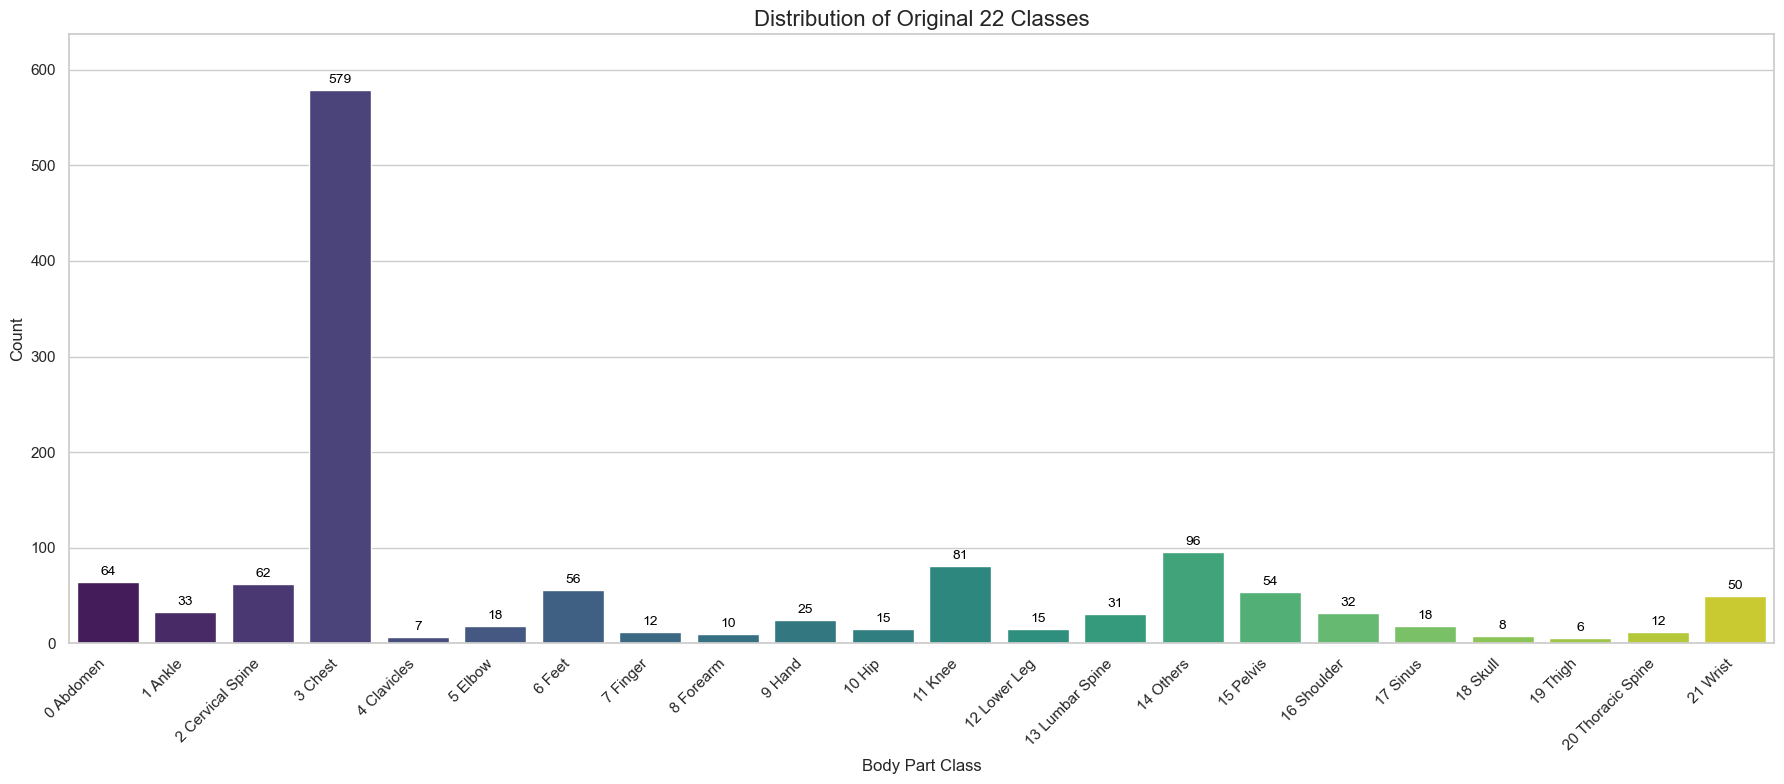

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 定義22類名稱
class_names = {
    0: "0 Abdomen", 1: "1 Ankle", 2: "2 Cervical Spine", 3: "3 Chest",
    4: "4 Clavicles", 5: "5 Elbow", 6: "6 Feet", 7: "7 Finger",
    8: "8 Forearm", 9: "9 Hand", 10: "10 Hip", 11: "11 Knee",
    12: "12 Lower Leg", 13: "13 Lumbar Spine", 14: "14 Others", 15: "15 Pelvis",
    16: "16 Shoulder", 17: "17 Sinus", 18: "18 Skull", 19: "19 Thigh",
    20: "20 Thoracic Spine", 21: "21 Wrist"
}

xtick_labels = [class_names[i] for i in range(22)]

# 繪圖
sns.set(style="whitegrid")

plt.figure(figsize=(18, 8)) # 稍微加寬加高，因為標籤變長了

# 做分布圖
ax = sns.countplot(x=original_labels, palette="viridis", order=range(22))

# 標註每一類的具體數量
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='baseline',
                fontsize=10, color='black',
                xytext=(0, 5),
                textcoords='offset points')

plt.xticks(ticks=range(22), labels=xtick_labels, rotation=45, ha='right')

plt.title('Distribution of Original 22 Classes', fontsize=16)
plt.xlabel('Body Part Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.ylim(0, pd.Series(original_labels).value_counts().max() * 1.1)

plt.tight_layout()
plt.show()

# 分配訓練集和驗證集

In [3]:
# --- 分割資料 (使用 22 類來分層) ---
X_train, X_val, y_train_22, y_val_22 = train_test_split(
    image_paths,
    original_labels,
    test_size=0.2,
    random_state=42,
    stratify=original_labels
)

In [4]:
# 定義自定義 Dataset 類別
class CustomDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        """
        初始化：建立路徑與標籤的對照表
        """
        self.image_paths = image_paths # 影像的路徑清單
        self.labels = labels           # 影像的標籤清單
        self.transform = transform     # 影像預處理
    def __len__(self):
        """
        回傳資料集總數：讓模型知道一輪訓練要跑幾張圖
        """
        return len(self.image_paths)

    def __getitem__(self, idx):
        """
        1. 根據索引 idx 找出路徑
        2. 從硬碟讀取影像並轉為 RGB
        3. 套用預處理
        4. 回傳處理後的影像與標籤
        """
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB') # 統一轉為三通道
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image) # 執行縮放、標準化等

        return image, label



# 八大類分類任務

In [5]:
# 訓練集的數據預處理和增強
transform = transforms.Compose([
    transforms.Pad(padding=(10, 10, 10, 10), fill=0, padding_mode='constant'),  # 在四周填充 10 像素，用常數填充（0）
    transforms.Resize((224, 224)),  # 然後調整圖像大小到 224x224
    transforms.RandomHorizontalFlip(p=0.5),  # 隨機水平翻轉
    transforms.RandomVerticalFlip(p=0.5),  # 隨機垂直翻轉
    transforms.RandomRotation(degrees=15),  # 隨機旋轉
    transforms.ColorJitter(brightness=0.15, contrast=0.15),  # 顏色抖動
    transforms.ToTensor(),  # 轉換為 Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # 標準化
])

# 驗證集的數據預處理
val_transform = transforms.Compose([
    transforms.Pad(padding=(10, 10, 10, 10), fill=0, padding_mode='constant'),  # 填充
    transforms.Resize((224, 224)),  # 然後調整圖像大小到 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 建立 22 類資料集 ---
# 傳入 y_train_22 與 y_val_22
train_dataset = CustomDataset(X_train, y_train_22, transform=transform)
val_dataset = CustomDataset(X_val, y_val_22, transform=val_transform)

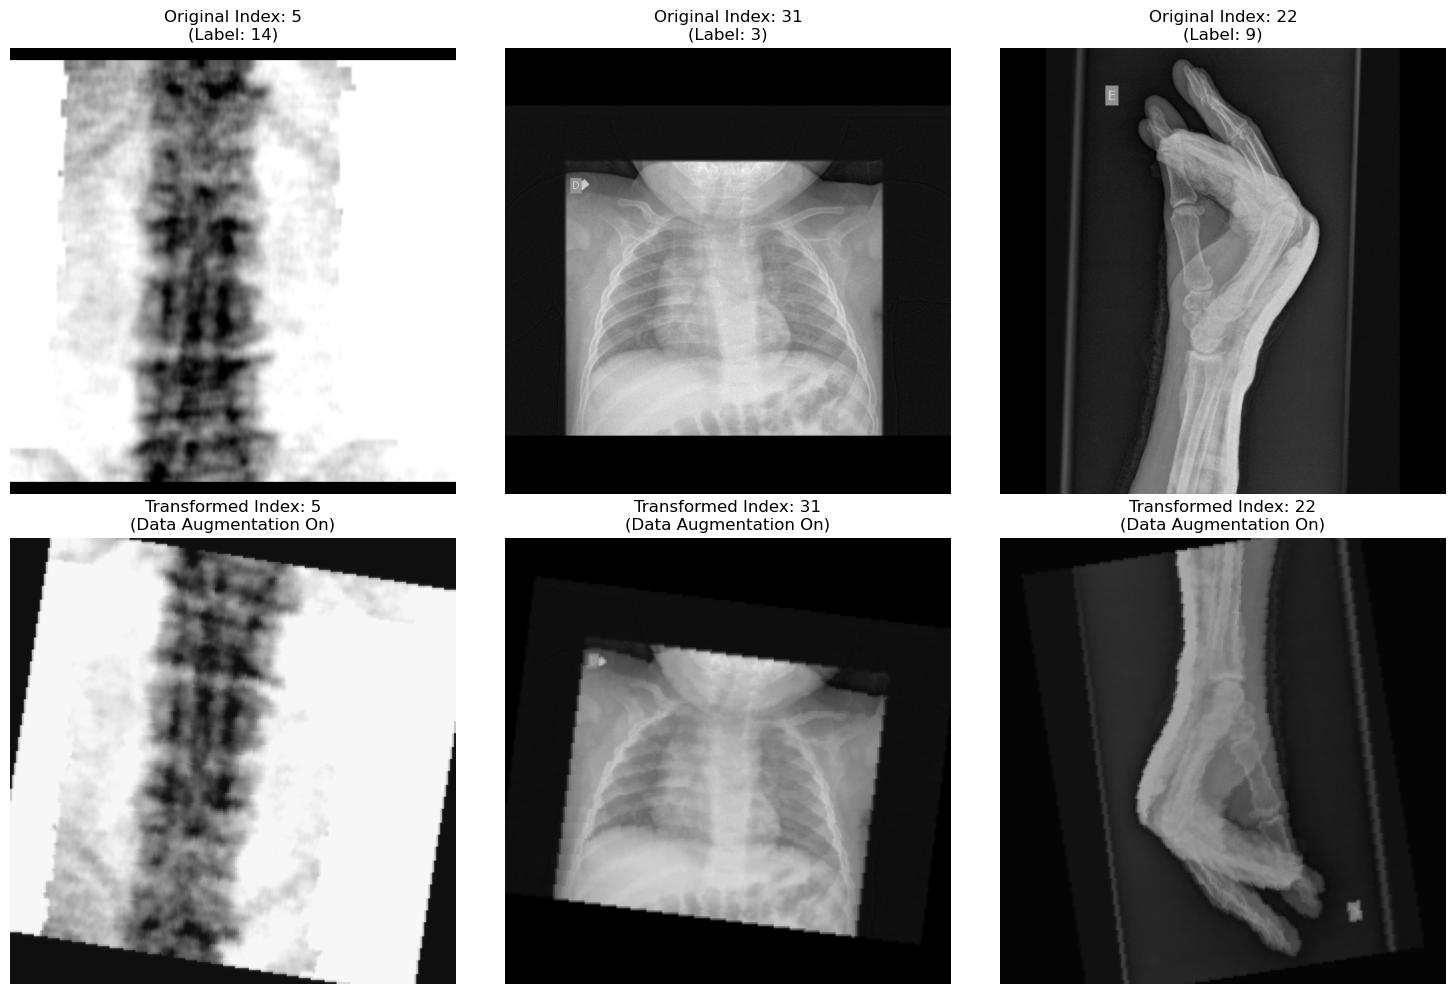

In [40]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# 訓練集抽樣索引 
fixed_indices = [5, 31 , 22]
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# 2x3
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, idx in enumerate(fixed_indices):
    # --- 上排：顯示原始影像 ---
    img_raw = Image.open(X_train[idx])
    axes[0, i].imshow(img_raw)
    axes[0, i].set_title(f"Original Index: {idx}\n(Label: {y_train_22[idx]})")
    axes[0, i].axis('off')

    # --- 下排：顯示預處理後影像 ---
    img_tensor, label = train_dataset[idx]
    
    # 將 Tensor (C, H, W) 轉為 Numpy (H, W, C) 並反標準化
    img_transformed = img_tensor.numpy().transpose((1, 2, 0))
    img_transformed = std * img_transformed + mean
    img_transformed = np.clip(img_transformed, 0, 1)
    
    axes[1, i].imshow(img_transformed)
    axes[1, i].set_title(f"Transformed Index: {idx}\n(Data Augmentation On)")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

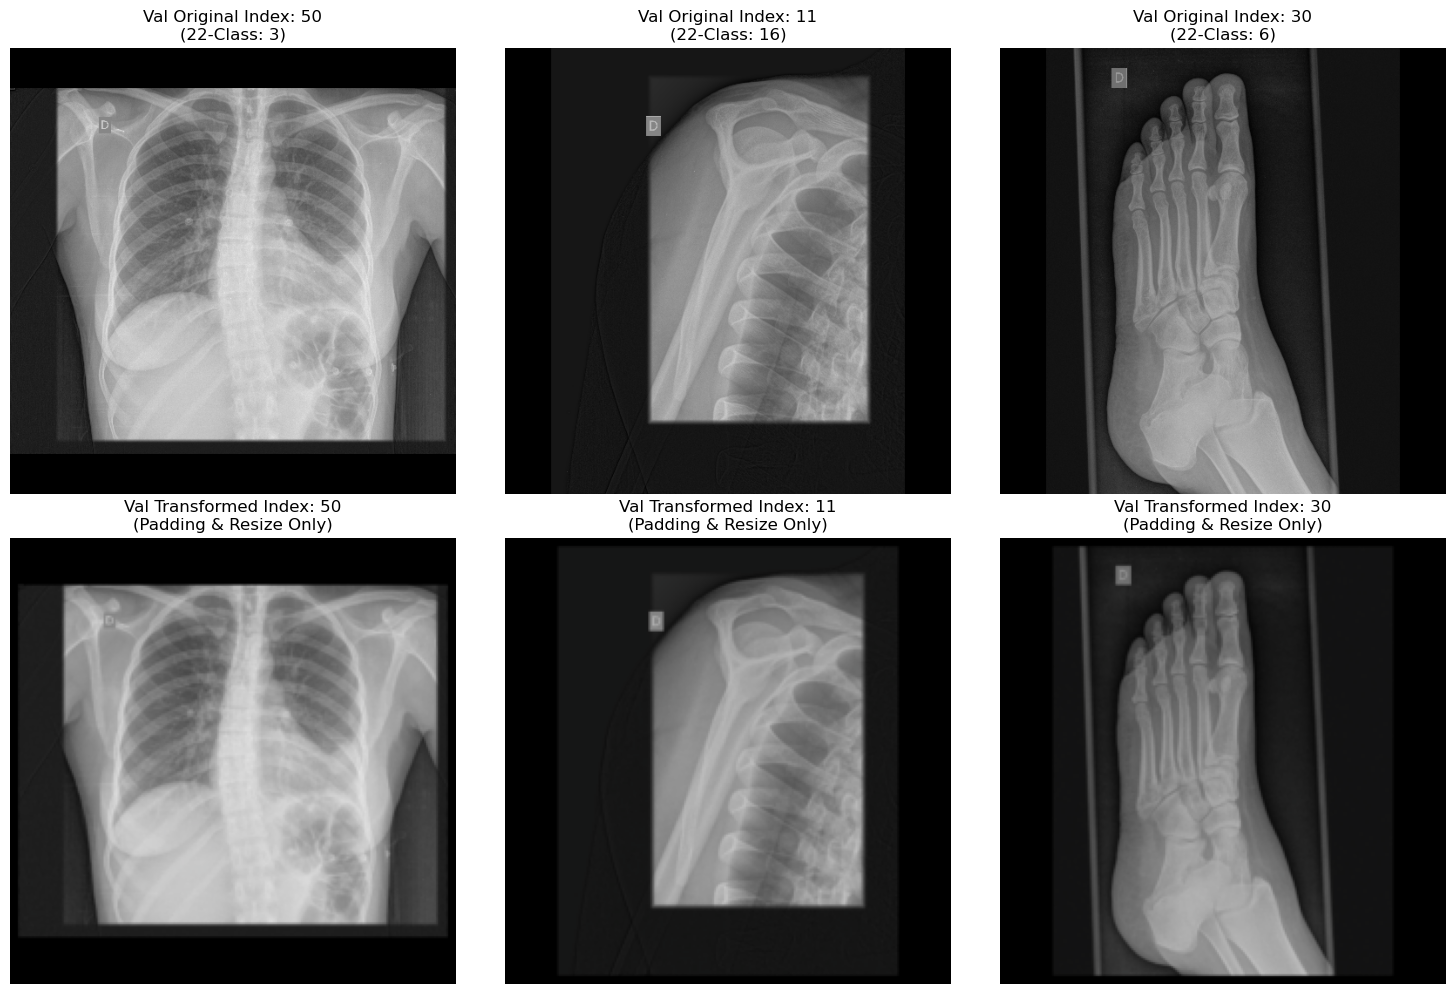

In [44]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# 驗證集抽樣索引 
fixed_indices = [50, 11, 30]
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# 2 列 x 3 欄
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, idx in enumerate(fixed_indices):
    # --- 上排：驗證集原始影像---
    img_raw = Image.open(X_val[idx])
    axes[0, i].imshow(img_raw)
    axes[0, i].set_title(f"Val Original Index: {idx}\n(22-Class: {y_val_22[idx]})")
    axes[0, i].axis('off')

    # --- 下排：驗證集預處理後影像---
    # 從 val_dataset 提取已經過 val_transform 的 Tensor
    img_tensor, label = val_dataset[idx]
    
    img_transformed = img_tensor.numpy().transpose((1, 2, 0))
    img_transformed = std * img_transformed + mean
    img_transformed = np.clip(img_transformed, 0, 1)
    
    axes[1, i].imshow(img_transformed)
    axes[1, i].set_title(f"Val Transformed Index: {idx}\n(Padding & Resize Only)")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 考慮到類別不平衡，分別嘗試有無調整權重，兩種方式調整



In [6]:
# --- 未針對各類別數量調整權重的DataLoader ---
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [6]:
import torch
from torch.utils.data import WeightedRandomSampler
import numpy as np
from collections import Counter

# 1. 自動計算每個類別的樣本數量 (確保順序對應 0~21)
# 這裡使用 y_train_22 (也就是你分割後的 22 類訓練標籤)
counts_dict = Counter(y_train_22)
class_counts = [counts_dict[i] for i in range(22)]
num_samples = sum(class_counts)

# 2. 計算類別權重
# 建議使用「開根號」平滑化：這能防止小類別權重過大導致模型過擬合
class_weights = [np.sqrt(num_samples / c) if c > 0 else 0 for c in class_counts]

# 3. 為訓練集中的每一張圖片分配權重
# 使用 y_train_22 作為索引來對應 class_weights
weights = [class_weights[label] for label in y_train_22]
weights = torch.DoubleTensor(weights)

# 4. 建立 Sampler
# replacement=True 允許重複抽樣小類別圖片
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

# 5. 修改 DataLoader
# 22 類建議 Batch Size 設為 64，讓梯度更新更頻繁，對小類別學習較好
train_loader = DataLoader(
    train_dataset,
    batch_size=64, 
    sampler=sampler,
    shuffle=False
)

# 驗證集不需要 sampler
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"22 類權重計算完成，最小類別權重倍率: {max(class_weights):.2f}")

22 類權重計算完成，最小類別權重倍率: 14.33


# Model building_ConvNeXt

In [7]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import torch.nn as nn

from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import torch.nn as nn

def build_convnext_v3(num_classes=22):
    # 提高隨機深度 (Stochastic Depth)：這對緩解過擬合極其有效
    model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT, stochastic_depth_prob=0.3)
    
    # 凍結前段，解凍後段
    for param in model.parameters():
        param.requires_grad = False
    
    # 解凍 Stage 3, 4 (Fine-tuning)
    for param in model.features[6:].parameters():
        param.requires_grad = True

    # 強化的分類頭
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(
        nn.BatchNorm1d(in_features), # 在進入線性層前先做歸一化
        nn.Linear(in_features, 512),
        nn.GELU(),
        nn.Dropout(0.5),             # 將 Dropout 調高至 0.5 (針對 22 類)
        nn.Linear(512, num_classes)
    )
    
    return model

model = build_convnext_v3(num_classes=22).to(device)
print(f"✅ 模型已成功更換為 ConvNeXt-Tiny 並搬移至 {device}")

✅ 模型已成功更換為 ConvNeXt-Tiny 並搬移至 mps


In [8]:
# 模型儲存路徑
model_path = "ConvNeXt_Tiny_22Classes_Best.pth"

if os.path.exists(model_path):
    print(f"✅ 發現預訓練模型: {model_path}，嘗試載入...")
    try:
        # 載入權重
        state_dict = torch.load(model_path, map_location=device)
        
        # 使用 strict=False 可以允許微小的結構差異，但模型種類不同(ConvNeXt vs ResNet)依然會失敗
        model.load_state_dict(state_dict, strict=True) 
        print("🚀 成功恢復 ConvNeXt 模型權重！接續訓練")
        
    except Exception as e:
        print(f"⚠️ 載入失敗：{e}")
        print("原因：可能是因為你更換了模型架構（從 ResNet 改為 ConvNeXt）。")
        print("系統將改用 ConvNeXt 預設的 ImageNet 權重重新開始訓練。")
else:
    print("ℹ️ 找不到存檔，將從 ConvNeXt 的原始預訓練權重開始（ImageNet-1K）。")


ℹ️ 找不到存檔，將從 ConvNeXt 的原始預訓練權重開始（ImageNet-1K）。


# Compile the model

In [9]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.optim as optim
import torch.nn as nn

# 確保使用GPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
model.to(device)
print(f"✅ 模型已搬移至: {device}")

# 定義損失函數
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 優化器，Adam+L2正則化
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=1e-4, 
    weight_decay=0.05 
)
# 設置學習率調度器
scheduler = ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    patience=3,     
    factor=0.2,     
    threshold=1e-4
)

✅ 模型已搬移至: mps


# Start training

In [10]:
import time
train_history = {
    'loss': [], 
    'accuracy': [], 
    'val_loss': [], 
    'val_accuracy': []
}
# --- 修正與建議優化點 ---
num_epochs = 30           
patience_limit = 5       
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(num_epochs):
    start_time = time.time()
    
    # --- 1. 訓練階段 ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    train_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train")
    
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        train_bar.set_postfix(loss=loss.item())

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    # --- 2. 驗證階段 ---
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader: # 確保名稱與你定義的一致
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels) # 這裡產生了 loss
            
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # 計算最終的驗證損失
    val_loss = val_running_loss / len(val_loader) 
    val_accuracy = 100 * val_correct / val_total

    # --- 3. 更新與紀錄 ---
    scheduler.step(val_loss) 
    current_lr = optimizer.param_groups[0]['lr']
    
    train_history['loss'].append(train_loss)
    train_history['accuracy'].append(train_accuracy)
    train_history['val_loss'].append(val_loss)
    train_history['val_accuracy'].append(val_accuracy)

    # --- 4. 早停與儲存 ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_convnext_22class.pth")
        print(f"⭐ 發現更佳模型！已儲存 (Val Loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"❄️ 未改進次數: {patience_counter}/{patience_limit}")

    epoch_time = time.time() - start_time
    print(f"📊 Epoch {epoch+1}: Train Acc {train_accuracy:.2f}% | Val Acc {val_accuracy:.2f}% | LR {current_lr:.6f} | Time {epoch_time:.2f}s")

    if device.type == 'mps':
        torch.mps.empty_cache()

    if patience_counter >= patience_limit:
        print("🛑 Early stopping triggered!")
        break

# --- 訓練結束後的最後一哩路 ---
print("🏁 訓練完成！正在載入最佳權重進行測試...")
model.load_state_dict(torch.load("best_convnext_22classes.pth"))
# 這裡接你的 evaluate_model(model, test_loader) 函數

Epoch [1/30] Train:   0%|          | 0/17 [00:00<?, ?it/s]

⭐ 發現更佳模型！已儲存 (Val Loss: 2.2209)
📊 Epoch 1: Train Acc 37.39% | Val Acc 66.54% | LR 0.000100 | Time 17.97s


Epoch [2/30] Train:   0%|          | 0/17 [00:00<?, ?it/s]

⭐ 發現更佳模型！已儲存 (Val Loss: 1.7726)
📊 Epoch 2: Train Acc 62.22% | Val Acc 70.82% | LR 0.000100 | Time 17.34s


Epoch [3/30] Train:   0%|          | 0/17 [00:00<?, ?it/s]

...

Epoch [29/30] Train:   0%|          | 0/17 [00:00<?, ?it/s]

❄️ 未改進次數: 1/5
📊 Epoch 29: Train Acc 94.64% | Val Acc 91.83% | LR 0.000100 | Time 20.47s


Epoch [30/30] Train:   0%|          | 0/17 [00:00<?, ?it/s]

❄️ 未改進次數: 2/5
📊 Epoch 30: Train Acc 94.74% | Val Acc 92.22% | LR 0.000100 | Time 19.98s
🏁 訓練完成！正在載入最佳權重進行測試...


<All keys matched successfully>

# Draw the training processing plot

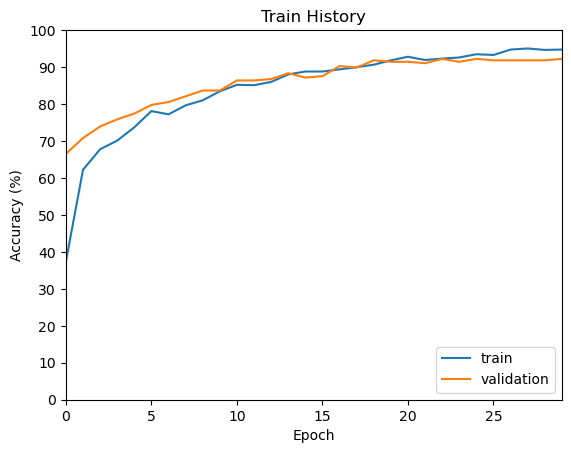

In [11]:
import matplotlib.pyplot as plt

# 繪製訓練和驗證的準確率
plt.plot(train_history['accuracy'])
plt.plot(train_history['val_accuracy'])

# 設定圖表標題和軸標籤
plt.title('Train History')
plt.ylabel('Accuracy (%)')
plt.xlabel('Epoch')

# 設定圖例
plt.legend(['train', 'validation'], loc='lower right')

# 設定 X 軸和 Y 軸的範圍從 0 開始
plt.xlim(0, len(train_history['accuracy']) - 1)  # X 軸從 0 到最大 epoch
plt.ylim(0, 100)  # Y 軸從 0 到 100

# 設定 Y 軸刻度間距為 10
plt.yticks(np.arange(0, 110, 10))
plt.show()

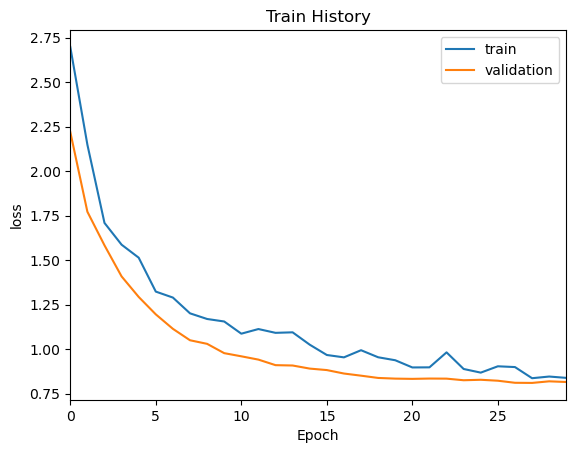

In [12]:
import matplotlib.pyplot as plt

# 繪製訓練和驗證的準確率
plt.plot(train_history['loss'])
plt.plot(train_history['val_loss'])

# 設定圖表標題和軸標籤
plt.title('Train History')
plt.ylabel('loss')
plt.xlabel('Epoch')

# 設定圖例
plt.legend(['train', 'validation'], loc='upper right')
plt.xlim(0, len(train_history['accuracy']) - 1)  # X 軸從 0 到最大 epoch
plt.show()

In [13]:
# 驗證和測試模型
def evaluate_model(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    loss = running_loss / len(data_loader)
    accuracy = 100 * correct / total
    return loss, accuracy


In [14]:
train_loss, train_accuracy = evaluate_model(model, train_loader)
print(f"Train Loss: {train_loss}, Train Accuracy: {train_accuracy}%")

val_loss, val_accuracy = evaluate_model(model, val_loader)
print(f"Validation Loss: {val_loss}, Validation Accuracy: {val_accuracy}%")


Train Loss: 0.7383224297972286, Train Accuracy: 97.95520934761441%
Validation Loss: 0.8244463682174683, Validation Accuracy: 92.21789883268482%


# Testing

In [15]:
# --- 讀取csv  ---
test_csv_path = "test_data.csv"
test_data = pd.read_csv(test_csv_path)

# 提取 SOPInstanceUID 和 22 類原始標籤
test_sop_instance_uids = test_data['SOPInstanceUID'].values
test_labels_22 = test_data['Target'].values 

# --- 2.準備影像路徑 ---
test_image_base_dir = "test"
test_image_paths = [os.path.join(test_image_base_dir, f"{uid}-c.png") for uid in test_sop_instance_uids]

# --- 3.建立測試數據集與 DataLoader ---
test_dataset = CustomDataset(test_image_paths, test_labels_22, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) 

# --- 4. 載入最佳權重 ---
best_model_path = "best_convnext_22classes.pth"
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"🚀 已載入 22 類最佳模型權重進行測試！")
else:
    print("找不到儲存的權重檔，將使用當前模型狀態進行測試。")

# --- 5.執行評估 ---
model.eval() # 確保進入評估模式
test_loss, test_accuracy = evaluate_model(model, test_loader)

print("-" * 30)
print(f"🏁 22 類測試結果:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print("-" * 30)

🚀 已載入 22 類最佳模型權重進行測試！
------------------------------
🏁 22 類測試結果:
Test Loss: 0.8397
Test Accuracy: 92.86%
------------------------------


In [23]:
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# 收集預測機率與真實標籤
model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        # 使用 Softmax 取得 0~1 之間的機率值
        probs = F.softmax(outputs, dim=1)
        
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

Y_bin = label_binarize(all_labels, classes=[0, 1, 2, 3, 4, 5, 6, 7,8, 9, 10,11, 12, 13, 14, 15, 16, 17,18,19,20,21])
n_classes = Y_bin.shape[1]

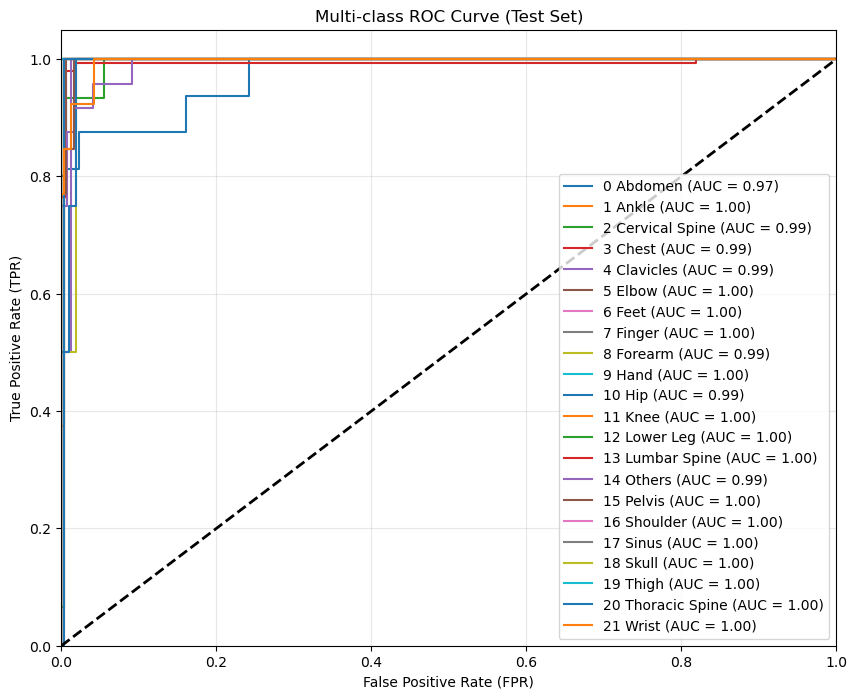

In [29]:
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(Y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Multi-class ROC Curve (Test Set)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

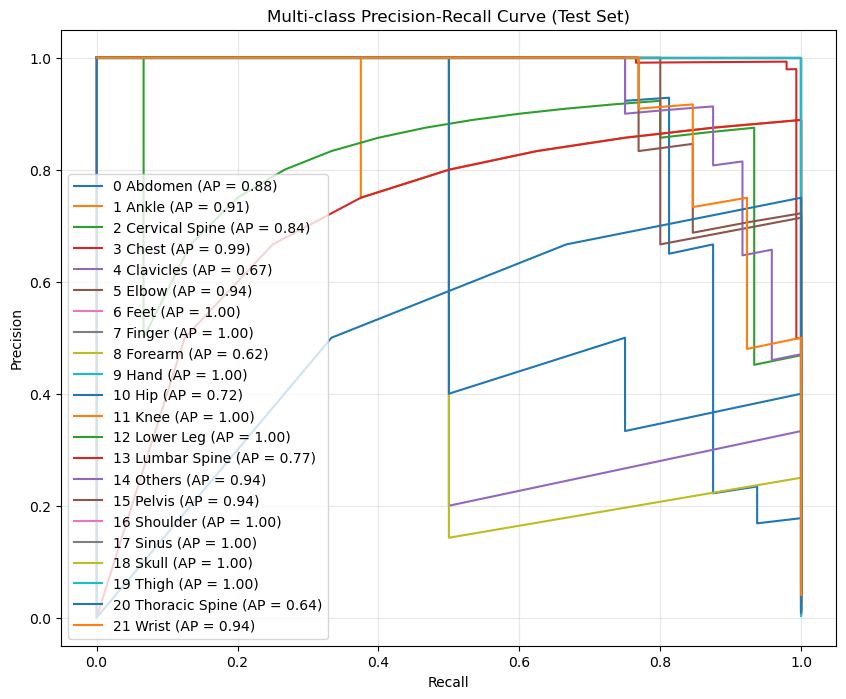

In [30]:
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(Y_bin[:, i], all_probs[:, i])
    average_precision = average_precision_score(Y_bin[:, i], all_probs[:, i])
    plt.plot(recall, precision, label=f'{class_names[i]} (AP = {average_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Multi-class Precision-Recall Curve (Test Set)')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

In [31]:
from sklearn.metrics import classification_report, confusion_matrix

#Precision, Recall/Sensitivity, F1-score
report = classification_report(all_labels, predicted_labels, 
                                target_names=class_names, output_dict=True)

# Specificity
def calculate_specificity(cm):
    specificities = []
    for i in range(len(cm)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(specificity)
    return specificities

cm = confusion_matrix(all_labels, predicted_labels)
specificities = calculate_specificity(cm)

# 印表格
print(f"{'Class':<15} | {'Sens.':<7} | {'Spec.':<7} | {'Prec.':<7} | {'F1':<7}")
print("-" * 60)
for i, name in enumerate(class_names):
    sens = report[name]['recall']      # Sensitivity
    prec = report[name]['precision']
    f1 = report[name]['f1-score']
    spec = specificities[i]            # Specificity
    
    print(f"{name:<15} | {sens:.4f} | {spec:.4f} | {prec:.4f} | {f1:.4f}")

Class           | Sens.   | Spec.   | Prec.   | F1     
------------------------------------------------------------
0 Abdomen       | 0.8125 | 0.9935 | 0.8667 | 0.8387
1 Ankle         | 1.0000 | 0.9968 | 0.8889 | 0.9412
2 Cervical Spine | 0.9333 | 0.9902 | 0.8235 | 0.8750
3 Chest         | 0.9931 | 0.9774 | 0.9730 | 0.9829
4 Clavicles     | 0.5000 | 1.0000 | 1.0000 | 0.6667
5 Elbow         | 0.8000 | 1.0000 | 1.0000 | 0.8889
6 Feet          | 0.9286 | 1.0000 | 1.0000 | 0.9630
7 Finger        | 1.0000 | 1.0000 | 1.0000 | 1.0000
8 Forearm       | 0.5000 | 1.0000 | 1.0000 | 0.6667
9 Hand          | 1.0000 | 1.0000 | 1.0000 | 1.0000
10 Hip          | 0.5000 | 0.9937 | 0.5000 | 0.5000
11 Knee         | 1.0000 | 0.9967 | 0.9545 | 0.9767
12 Lower Leg    | 1.0000 | 0.9937 | 0.6667 | 0.8000
13 Lumbar Spine | 1.0000 | 0.9968 | 0.8889 | 0.9412
14 Others       | 0.7500 | 1.0000 | 1.0000 | 0.8571
15 Pelvis       | 0.7692 | 0.9935 | 0.8333 | 0.8000
16 Shoulder     | 0.8750 | 0.9968 | 0.8750 | 0.875

# Confusion Matrix

In [16]:
# 預測
model.eval()
predictions = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        predictions.extend(predicted.cpu().numpy())

predicted_class_indices = np.array(predictions)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 獲取第一個批次
for batch_test_img, batch_test_label in test_dataset:
    print(batch_test_img.shape)  # 圖像的形狀
    print(batch_test_label)  # 標籤的形狀
    break  # 只取第一個批次

torch.Size([3, 224, 224])
3


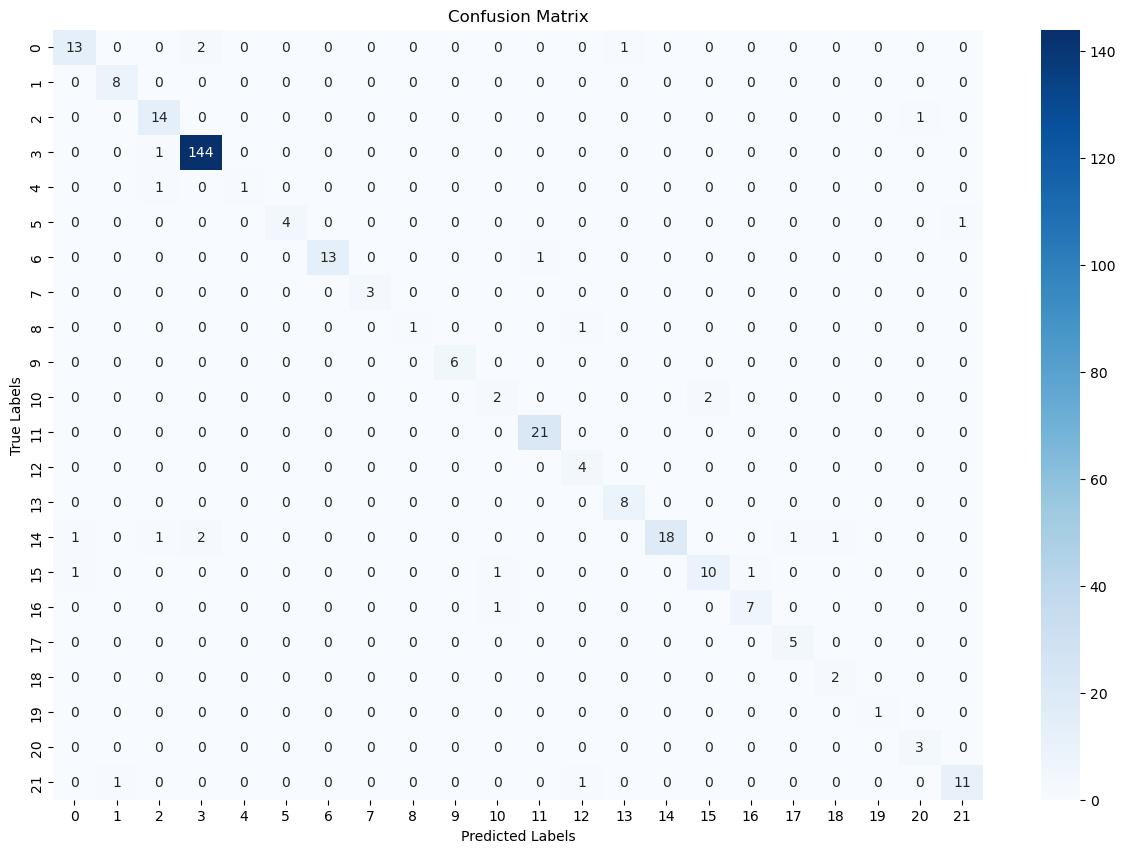

In [18]:
# 初始化空列表來存儲真實標籤和預測結果
true_labels = []
predicted_labels = []

# 遍歷 test_dataset
model.eval()  # 設置模型為評估模式
with torch.no_grad():  # 禁用梯度計算
    for batch_images, batch_labels in test_loader:
        # 將數據移動到設備（如 GPU）
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        # 獲取模型的預測結果
        outputs = model(batch_images)
        _, batch_predicted_indices = torch.max(outputs, 1)  # 獲取預測類別索引

        # 將真實標籤和預測結果添加到列表中
        true_labels.extend(batch_labels.cpu().numpy())
        predicted_labels.extend(batch_predicted_indices.cpu().numpy())

# 將列表轉換為 NumPy 數組
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# 計算混淆矩陣
CNN_confusion_matrix = confusion_matrix(true_labels, predicted_labels)

# 繪製混淆矩陣
plt.figure(figsize=(15, 10))
sns.heatmap(CNN_confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Grad-CAM

In [26]:
# --- 從 test_loader 抓取資料 ---
dataiter = iter(test_loader)
images, labels = next(dataiter)

input_tensor = images[0].unsqueeze(0).to(device)
input_tensor.requires_grad = True # Grad-CAM 必須開啟梯度
true_label = labels[0].item()

# --- 將 Tensor 還原為可顯示的 RGB 圖片 ---
def get_rgb_visualization(tensor):
    # 這是 ImageNet 的標準均值與標準差，需還原
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # [1, 3, 224, 224] -> [3, 224, 224] -> [224, 224, 3]
    img = tensor[0].detach().cpu().permute(1, 2, 0).numpy()
    img = img * std + mean # 反標準化
    img = np.clip(img, 0, 1) # 確保數值在 0~1 之間
    return img

# 建立變數
rgb_img = get_rgb_visualization(input_tensor)

# --- 取得模型預測結果 ---
model.eval()
with torch.no_grad():
    output = model(input_tensor)
    predicted_label = torch.max(output, 1)[1].item()

print(f"✅ 變數準備就緒！")
print(f"真實: {class_names[true_label]} | 預測: {class_names[predicted_label]}")

✅ 變數準備就緒！
真實: 3 Chest | 預測: 3 Chest


In [27]:
model.eval()
wrong_image = None
wrong_pred = None
wrong_true = None

# 遍歷測試集，直到抓到第一張猜錯的圖
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        
        # 找出預測不等於真實的索引
        errors = (preds != lbls).nonzero()
        if len(errors) > 0:
            idx = errors[0].item() # 抓這個 batch 裡第一張錯的
            wrong_image = imgs[idx].unsqueeze(0)
            wrong_pred = preds[idx].item()
            wrong_true = lbls[idx].item()
            break

if wrong_image is not None:
    print(f"🚩 抓到錯誤案例！")
    print(f"真實標籤: {class_names[wrong_true]}")
    print(f"模型誤判為: {class_names[wrong_pred]}")
    
    input_tensor = wrong_image
    predicted_label = wrong_pred
    true_label = wrong_true
else:
    print("模型太準了，這個 Batch 竟然沒猜錯任何一張！")

🚩 抓到錯誤案例！
真實標籤: 15 Pelvis
模型誤判為: 10 Hip


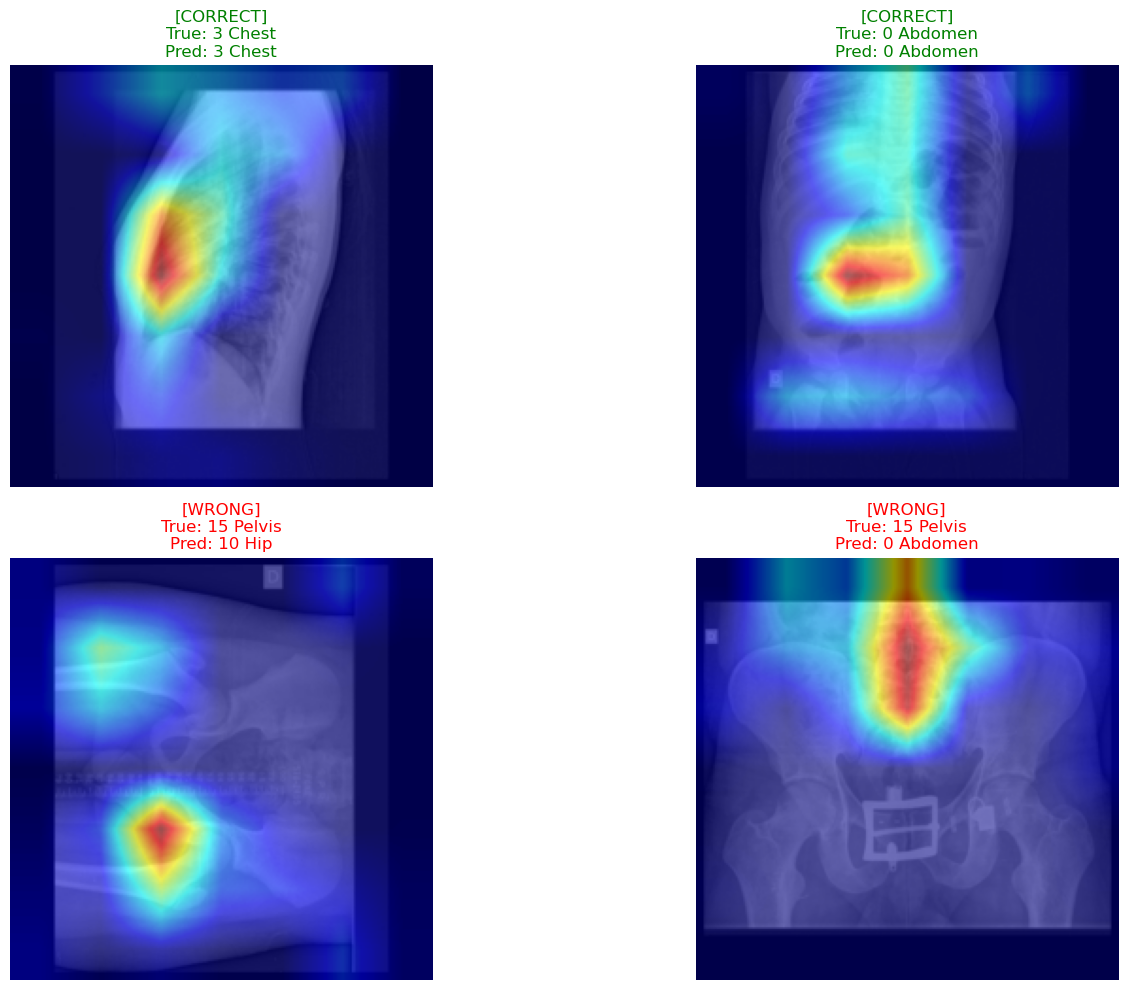

In [33]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

=
# 1. 初始化 Grad-CAM 
cam = GradCAM(model=model, target_layers=target_layers)

def get_rgb_visualization(tensor):
    # ImageNet 標準反標準化
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.detach().cpu().permute(1, 2, 0).numpy()
    img = img * std + mean
    return np.clip(img, 0, 1)

# 2. 收集樣本 (2正確 2錯誤)
correct_samples = []
wrong_samples = []

model.eval()
# 算梯度用 no_grad 
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs_dev = imgs.to(device)
        outputs = model(imgs_dev)
        _, preds = torch.max(outputs, 1)
        
        for i in range(len(preds)):
            sample_data = {
                'img': imgs[i].unsqueeze(0),
                'true': lbls[i].item(),
                'pred': preds[i].item()
            }
            if preds[i] == lbls[i] and len(correct_samples) < 2:
                correct_samples.append(sample_data)
            elif preds[i] != lbls[i] and len(wrong_samples) < 2:
                wrong_samples.append(sample_data)
        
        if len(correct_samples) >= 2 and len(wrong_samples) >= 2:
            break

all_samples = correct_samples + wrong_samples

# 3. 繪圖
plt.figure(figsize=(16, 10))

for i, sample in enumerate(all_samples):
    input_tensor = sample['img'].to(device)
    # requires_grad開
    input_tensor.requires_grad = True 
    
    # 建立原圖
    rgb_img = get_rgb_visualization(sample['img'][0])
    
    # 產生模型預測類別的熱力圖
    targets = [ClassifierOutputTarget(sample['pred'])]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    # 正確綠色，錯誤紅色
    is_correct = sample['true'] == sample['pred']
    title_color = 'green' if is_correct else 'red'
    status = "CORRECT" if is_correct else "WRONG"
    
    plt.subplot(2, 2, i + 1)
    plt.imshow(visualization)
    plt.title(f"[{status}]\nTrue: {class_names[sample['true']]}\nPred: {class_names[sample['pred']]}", 
              color=title_color, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()